In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [13]:
from google.colab import files

uploaded = files.upload()

Saving sales.csv to sales (1).csv


In [14]:
df = pd.read_csv("sales.csv")

df.head()

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,01-02-2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,01-02-2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,01-02-2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,01-02-2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,01-02-2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville


In [15]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

(23906, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Car_id         23906 non-null  object
 1   Date           23906 non-null  object
 2   Customer Name  23905 non-null  object
 3   Gender         23906 non-null  object
 4   Annual Income  23906 non-null  int64 
 5   Dealer_Name    23906 non-null  object
 6   Company        23906 non-null  object
 7   Model          23906 non-null  object
 8   Engine         23906 non-null  object
 9   Transmission   23906 non-null  object
 10  Color          23906 non-null  object
 11  Price ($)      23906 non-null  int64 
 12  Dealer_No      23906 non-null  object
 13  Body Style     23906 non-null  object
 14  Phone          23906 non-null  int64 
 15  Dealer_Region  23906 non-null  object
dtypes: int64(3), object(13)
memory usage: 2.9+ MB
None
Car_id           0
Date             0
Customer Na

In [16]:
df.drop_duplicates(inplace=True)

df["Date"] = pd.to_datetime(df["Date"], format='mixed')

print(df.shape)

(23906, 16)


In [17]:
customer_df = df.groupby("Customer Name").agg({
    "Price ($)":"sum",
    "Annual Income":"mean",
    "Car_id":"count"
}).reset_index()

customer_df.columns = [
    "Customer",
    "Total_Spending",
    "Income",
    "Purchase_Count"
]

customer_df.head()

,Customer,Total_Spending,Income,Purchase_Count
0,Aahil,69000,1.172500e+06,2
1,Aaliyah,600301,8.912647e+05,17
2,Aarav,236001,1.002750e+06,8
3,Aaron,1087010,7.739487e+05,39
4,Aarya,39000,5.867500e+05,2


In [18]:
customer_df.describe()

,Total_Spending,Income,Purchase_Count
count,3.021000e+03,3.021000e+03,3021.000000
mean,2.222709e+05,8.304841e+05,7.912943
std,3.105839e+05,5.259825e+05,10.957475
min,2.200000e+03,1.350000e+04,1.000000
25%,2.800000e+04,5.986250e+05,1.000000
50%,8.550200e+04,7.844286e+05,3.000000
75%,2.710020e+05,9.950000e+05,10.000000
max,2.796875e+06,6.600000e+06,92.000000


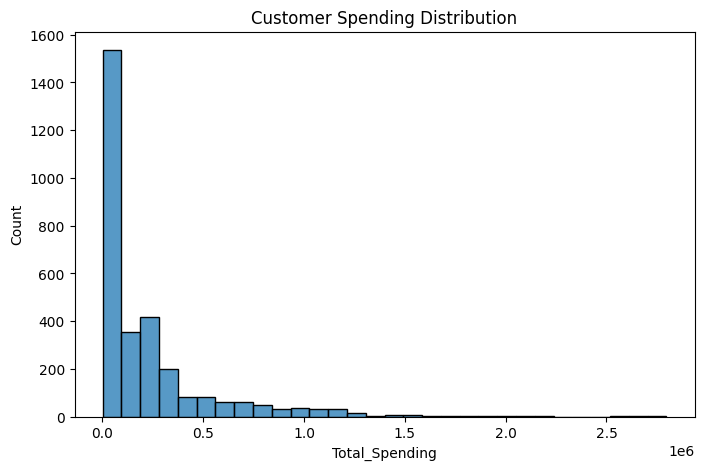

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(
    customer_df["Total_Spending"],
    bins=30
)

plt.title("Customer Spending Distribution")

plt.show()

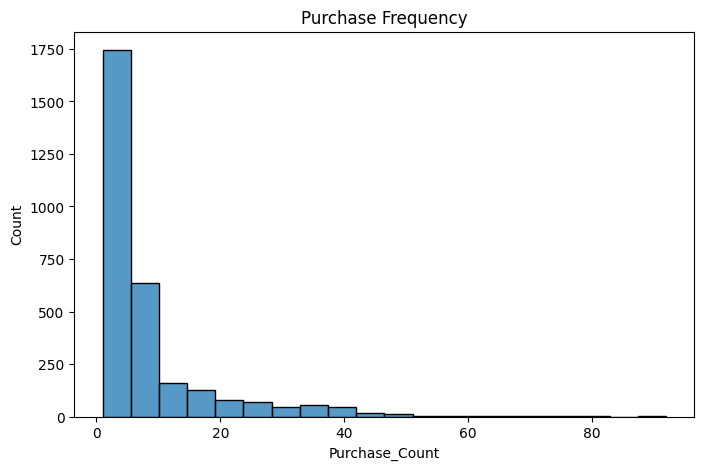

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    customer_df["Purchase_Count"],
    bins=20
)

plt.title("Purchase Frequency")

plt.show()

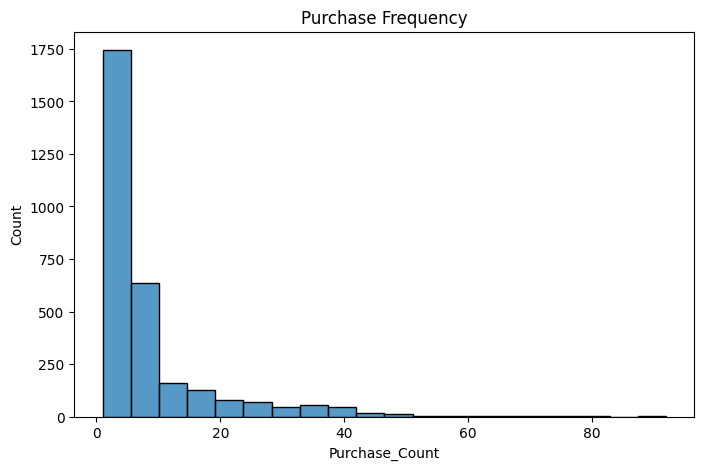

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    customer_df["Purchase_Count"],
    bins=20
)

plt.title("Purchase Frequency")

plt.show()

In [22]:
features = customer_df[
    ["Total_Spending",
     "Income",
     "Purchase_Count"]
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

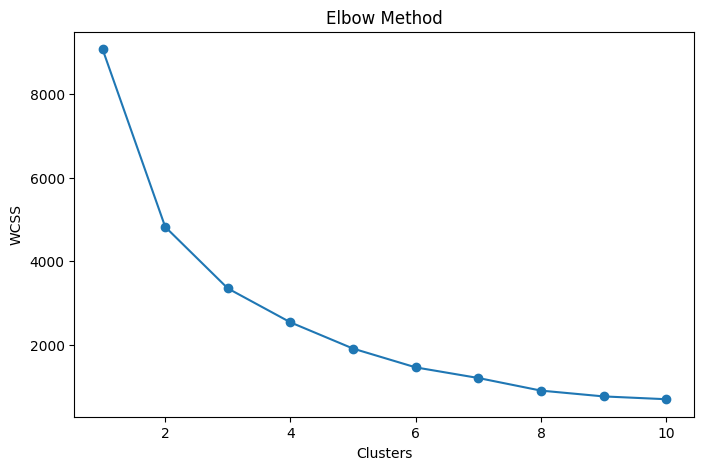

In [23]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(scaled_features)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.show()

In [24]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

customer_df["Cluster"] = kmeans.fit_predict(
    scaled_features
)

customer_df.head()

,Customer,Total_Spending,Income,Purchase_Count,Cluster
0,Aahil,69000,1.172500e+06,2,3
1,Aaliyah,600301,8.912647e+05,17,1
2,Aarav,236001,1.002750e+06,8,1
3,Aaron,1087010,7.739487e+05,39,2
4,Aarya,39000,5.867500e+05,2,0


In [25]:
cluster_summary = customer_df.groupby(
    "Cluster"
).mean(
    numeric_only=True
)

print(cluster_summary)

         Total_Spending        Income  Purchase_Count
Cluster                                              
0          5.719974e+04  5.740355e+05        2.106658
1          3.278923e+05  8.510523e+05       11.575556
2          1.045904e+06  8.332183e+05       37.149425
3          4.948026e+04  1.753854e+06        1.778351


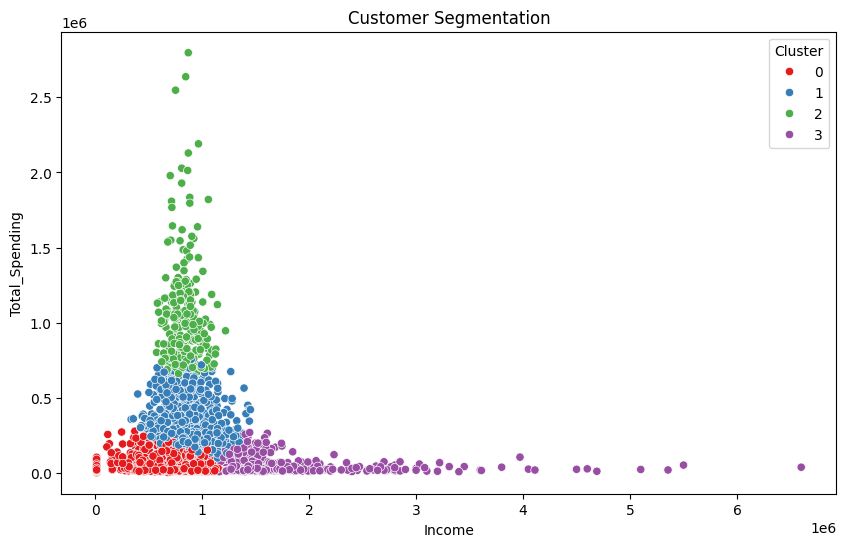

In [26]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=customer_df,
    x="Income",
    y="Total_Spending",
    hue="Cluster",
    palette="Set1"
)

plt.title(
    "Customer Segmentation"
)

plt.show()

In [27]:
customer_df["Cluster"].value_counts()

,count
Cluster,
0,1472
1,900
3,388
2,261


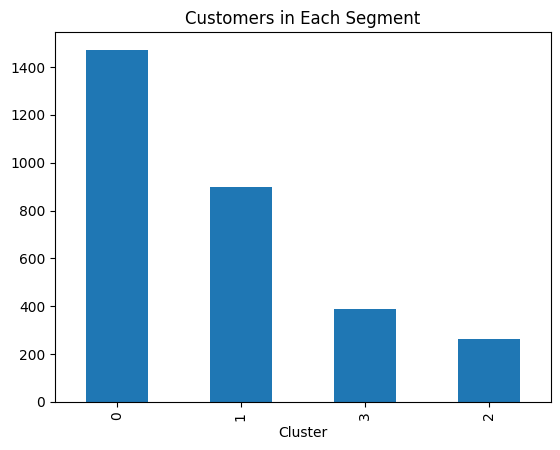

In [28]:
customer_df["Cluster"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Customers in Each Segment"
)

plt.show()

In [29]:
print("Customer Segmentation Insights")

print("\nCluster Sizes:")
print(customer_df["Cluster"].value_counts())

print("\nCluster Summary:")
print(cluster_summary)

Customer Segmentation Insights

Cluster Sizes:
Cluster
0    1472
1     900
3     388
2     261
Name: count, dtype: int64

Cluster Summary:
         Total_Spending        Income  Purchase_Count
Cluster                                              
0          5.719974e+04  5.740355e+05        2.106658
1          3.278923e+05  8.510523e+05       11.575556
2          1.045904e+06  8.332183e+05       37.149425
3          4.948026e+04  1.753854e+06        1.778351


In [30]:
customer_df.to_csv(
    "Customer_Segments.csv",
    index=False
)

print(
    "Customer_Segments.csv saved"
)

Customer_Segments.csv saved


In [31]:
print("""

PROJECT CONCLUSION

1. Customer purchase behavior analyzed.

2. Customers segmented using K-Means Clustering.

3. Spending and income patterns identified.

4. High-value customers detected.

5. Marketing target groups created.

6. Customer analytics insights generated.

Project Successfully Completed.

""")



PROJECT CONCLUSION

1. Customer purchase behavior analyzed.

2. Customers segmented using K-Means Clustering.

3. Spending and income patterns identified.

4. High-value customers detected.

5. Marketing target groups created.

6. Customer analytics insights generated.

Project Successfully Completed.


